In [2]:
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

from src.model import *
from src.utils import *
from src.dataset import *

import matplotlib.pyplot as plt 

import torch
from torch.utils.data import DataLoader

In [3]:
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initiate model with same hyperparameters
osc_branch_net = General_MLP(input_size  = 2, 
                             output_size = 50,
                             depth       = 4, 
                             hidden_size = 32, 
                             act         = nn.Tanh())

osc_trunk_net  = General_MLP(input_size  = 1, 
                             output_size = 50,
                             depth       = 4, 
                             hidden_size = 32, 
                             act         = nn.Tanh())

osc_deepONet   = DeepONet(branch_net  = osc_branch_net, 
                          trunk_net   = osc_trunk_net,
                          output_size = 1)

# 2. Load the saved weights into the model

state_dict = torch.load("/home/enricp/repos/PINNS/weights/best_1d_osc.pth", map_location=device)
osc_deepONet.load_state_dict(state_dict)
osc_deepONet = osc_deepONet.to(device)

# 3. Set to eval mode
osc_deepONet.eval()



# Initialize Harmonic Oscillator object

string_constant = 2
dampening_coeff = 0.1
args1           = [string_constant, dampening_coeff]

osc_sampler     = LatinHypercubeSampler(dimensions = 2, 
                                        lows       = [-1, -1], 
                                        highs      = [1, 1])

osc_object      = harm_osc(args1)



In [4]:
dataset_size = 1
batch_size   = 1
num_workers  = 8
t_span       = (0, 10)

osc_dataset = ODEIterableDataset(size          = dataset_size,
                                 system_class  = osc_object,
                                 sampler       = osc_sampler,
                                 t_span        = t_span,
                                 full_solution = True)

osc_loader  = DataLoader(dataset     = osc_dataset,
                         batch_size  = batch_size,
                         num_workers = num_workers)


In [5]:
# Single Sample for plotting
I, t, y = next(iter(osc_loader))

# Take first sample from batch
I = I[0]  # (2,)
t = t[0]  # (N,)
y = y[0]  # (N, 2) or (N,)

with torch.no_grad():
    t_tensor  = t.unsqueeze(1).to(device)          # (N, 1)
    u0_tensor = I.unsqueeze(0).expand(len(t), -1)  # (N, 2)
    u0_tensor = u0_tensor.to(device)

    model_sol = osc_deepONet(u0_tensor, t_tensor)  # (N, 1)
    model_sol = model_sol.cpu().numpy()


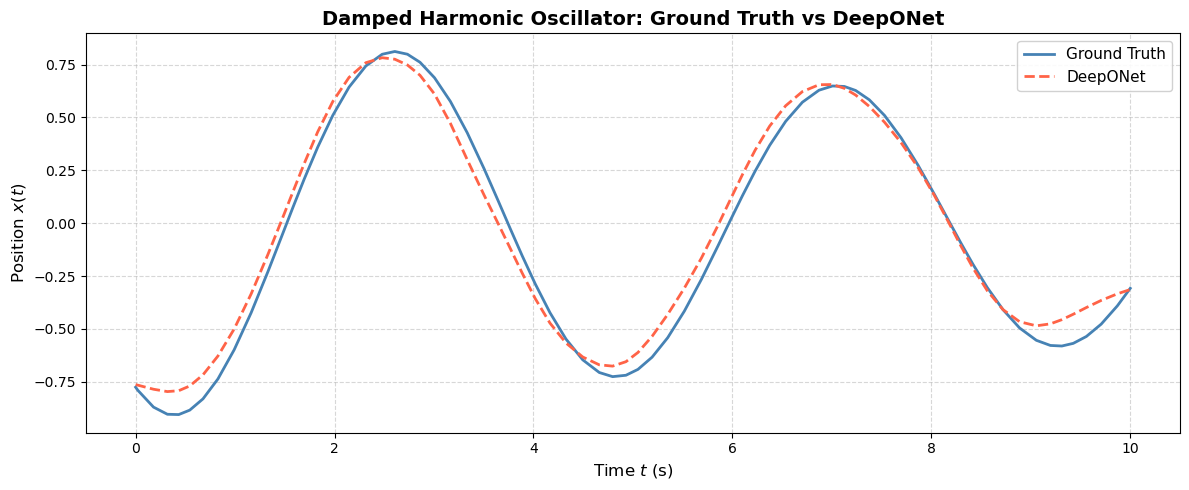

In [6]:
# Plotting 

plt.figure(figsize=(12, 5))
plt.plot(t, y[0], color="steelblue", lw=2, label="Ground Truth")
plt.plot(t, model_sol, color="tomato",    lw=2, label="DeepONet", linestyle="--")
plt.title("Damped Harmonic Oscillator: Ground Truth vs DeepONet", fontsize=14, fontweight="bold")
plt.ylabel("Position $x(t)$", fontsize=12)
plt.xlabel("Time $t$ (s)", fontsize=12)
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
import time

# Boxplots 

# Samples per 
num_samples = 1000
num_boxes   = 10

# Sample Generation
num_samples = 1000
y0_samples  = osc_sampler(num_samples)
times       = np.linspace(1, 10, num_boxes)

# ODE solver saving Data
solver        = ODEsolver(osc_object).solve 
solver_timing = []

# DeepOnet
nn_timing     = []
nn_accuracy   = []

loss_fn       = torch.nn.MSELoss()

with torch.no_grad():
    for t_val in times:
        solver_time = []
        nn_time     = []
        nn_MSE      = []

        for y in y0_samples:
            start = time.perf_counter()
            sol   = solver((0, t_val), y, t_eval=[t_val]).y[:, -1][0]
            end   = time.perf_counter()
            solver_time.append(end - start)

            sol_tensor = torch.tensor(sol, dtype=torch.float32).to(device)
            t_tensor = torch.tensor([[t_val]], dtype=torch.float32).to(device)  # shape (1,1)
            y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(0).to(device)

            start     = time.perf_counter()
            model_sol = osc_deepONet(y_tensor, t_tensor)
            end       = time.perf_counter()
            nn_time.append(end - start)
            nn_MSE.append(loss_fn(model_sol, sol_tensor))

        solver_timing.append(solver_time)
        nn_timing.append(nn_time)
        nn_accuracy.append(torch.stack(nn_MSE).mean())

            



/home/enricp/miniconda3/envs/physics/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


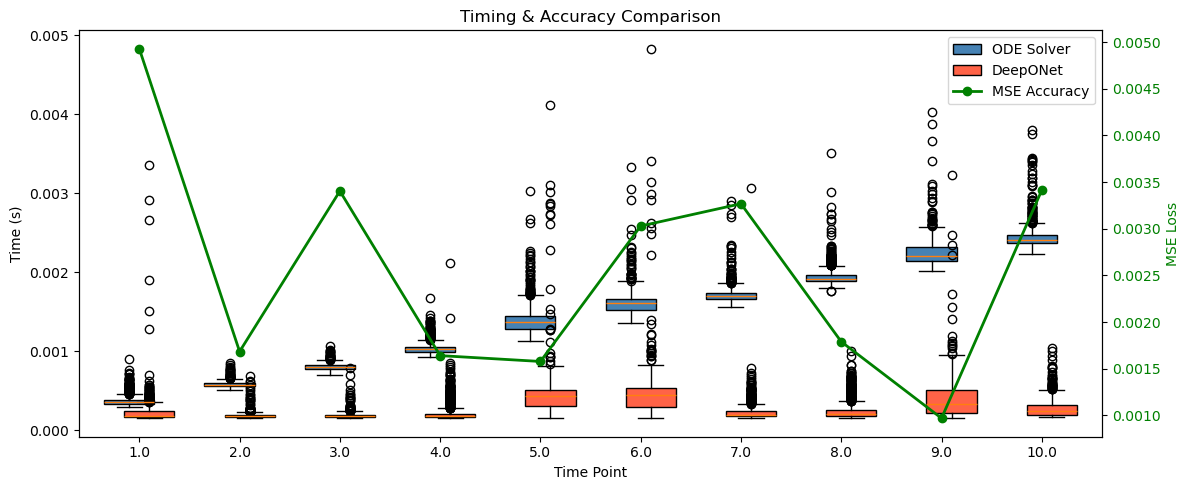

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 5))
labels = [f"{t:.1f}" for t in times]

# --- Timing boxplots ---
bp1 = ax1.boxplot(solver_timing, positions=np.arange(num_boxes) - 0.1,
                  widths=0.5, patch_artist=True)
bp2 = ax1.boxplot(nn_timing, positions=np.arange(num_boxes) + 0.1,
                  widths=0.5, patch_artist=True)

for patch in bp1['boxes']: patch.set_facecolor('steelblue')
for patch in bp2['boxes']: patch.set_facecolor('tomato')

ax1.set_xticks(np.arange(num_boxes))
ax1.set_xticklabels(labels)
ax1.set_xlabel("Time Point")
ax1.set_ylabel("Time (s)")

# --- Accuracy line on twin axis ---
ax2 = ax1.twinx()

nn_accuracy_np = [v.cpu().numpy() for v in nn_accuracy]  # fix GPU error

ax2.plot(np.arange(num_boxes), nn_accuracy_np,
         color='green', marker='o', linewidth=2, label='MSE')
ax2.set_ylabel("MSE Loss", color='green')
ax2.tick_params(axis='y', labelcolor='green')

# --- Legend ---
ax1.legend([bp1['boxes'][0], bp2['boxes'][0], ax2.lines[0]],
           ['ODE Solver', 'DeepONet', 'MSE Accuracy'])

plt.title("Timing & Accuracy Comparison")
plt.tight_layout()
plt.show()